In [16]:
# count number of non-zero pixels in BDE fits 

from pathlib import Path
import numpy as np
import pandas as pd
from astropy.io import fits

folder = Path("/home/bekah/m3_papers/20260311_bde_darkcurrent/bde_fits")

rows = []

for fits_path in folder.glob("*.fits"):
    file_id = fits_path.stem.split("_")[0]

    with fits.open(fits_path) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is None:
                continue

            data = np.asarray(hdu.data)

            zero_count = np.count_nonzero(data == 0)
            one_count = np.count_nonzero(data == 1)
            two_count = np.count_nonzero(data == 2)
            three_count = np.count_nonzero(data == 3)
            four_count = np.count_nonzero(data == 4)
            five_count = np.count_nonzero(data == 5)
            nonzero_count = np.count_nonzero(data)

            rows.append({
                "file_id": file_id,
                "filename": fits_path.name,
                "hdu": i,
                "zeros": zero_count,
                "nonzeros": nonzero_count,
                "fives":  five_count,
                "fours": four_count,
                "threes": three_count,
                "twos": two_count,
                "ones": one_count,
            })

df = pd.DataFrame(rows)

print(df)

                file_id                         filename  hdu   zeros  \
0    m3g20090103t080012      m3g20090103t080012_bde.fits    0   25193   
1    m3g20090611t041842      m3g20090611t041842_bde.fits    0   25064   
2    m3g20081212t015112      m3g20081212t015112_bde.fits    0    1684   
3    m3g20090531t130802      m3g20090531t130802_bde.fits    0   24997   
4    m3g20090607t110113  m3g20090607t110113_bde (1).fits    0   25345   
..                  ...                              ...  ...     ...   
468  m3g20090520t110308      m3g20090520t110308_bde.fits    0   25922   
469  m3g20090617t045332      m3g20090617t045332_bde.fits    0   22780   
470  m3t20090420t102514      m3t20090420t102514_bde.fits    0  159946   
471  m3g20090106t065011      m3g20090106t065011_bde.fits    0   25518   
472  m3g20090207t155050      m3g20090207t155050_bde.fits    0   26196   

     nonzeros  fives  fours  threes   twos  ones  
0        2327      0    640      27   1193   467  
1        2456      0 

In [17]:
# read temperature table
temps = pd.read_fwf("/home/bekah/m3_papers/20260310_darkcurrent/m3_detector_temperature.tab")

temps["id"] = temps["id"].str.lower()

# merge temp into df
df = df.merge(temps, left_on="file_id", right_on="id", how="left")

# optional: drop duplicate id column
df = df.drop(columns="id")


In [18]:
df

,file_id,filename,hdu,zeros,nonzeros,fives,fours,threes,twos,ones,temp
0,m3g20090103t080012,m3g20090103t080012_bde.fits,0,25193,2327,0,640,27,1193,467,164.04
1,m3g20090611t041842,m3g20090611t041842_bde.fits,0,25064,2456,0,640,36,1316,464,164.45
2,m3g20081212t015112,m3g20081212t015112_bde.fits,0,1684,25836,0,640,490,22915,335,175.64
3,m3g20090531t130802,m3g20090531t130802_bde.fits,0,24997,2523,0,640,34,1379,470,164.87
4,m3g20090607t110113,m3g20090607t110113_bde (1).fits,0,25345,2175,0,640,29,1048,458,163.37
...,...,...,...,...,...,...,...,...,...,...,...
468,m3g20090520t110308,m3g20090520t110308_bde.fits,0,25922,1598,0,640,22,492,444,158.09
469,m3g20090617t045332,m3g20090617t045332_bde.fits,0,22780,4740,0,640,66,3555,479,167.99
470,m3t20090420t102514,m3t20090420t102514_bde.fits,0,159946,6454,0,3975,532,557,1390,148.61
471,m3g20090106t065011,m3g20090106t065011_bde.fits,0,25518,2002,0,640,29,884,449,161.99


In [19]:
m3g = df[df["file_id"].str[2].str.lower() != "t"]

In [8]:
import matplotlib.pyplot as plt 

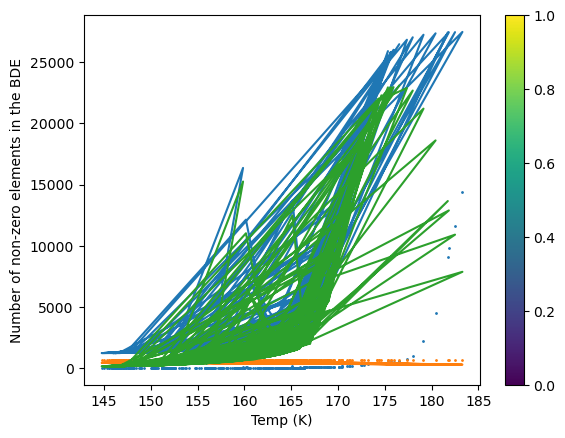

In [24]:
plt.plot(m3g['temp'], m3g['nonzeros'])
plt.plot(m3g['temp'], m3g['ones'])
plt.plot(m3g['temp'], m3g['twos'])
plt.scatter(m3g['temp'], m3g['threes'],s=1)
plt.scatter(m3g['temp'], m3g['fours'],s=1)
plt.xlabel("Temp (K)")
plt.ylabel("Number of non-zero elements in the BDE") 
plt.colorbar()

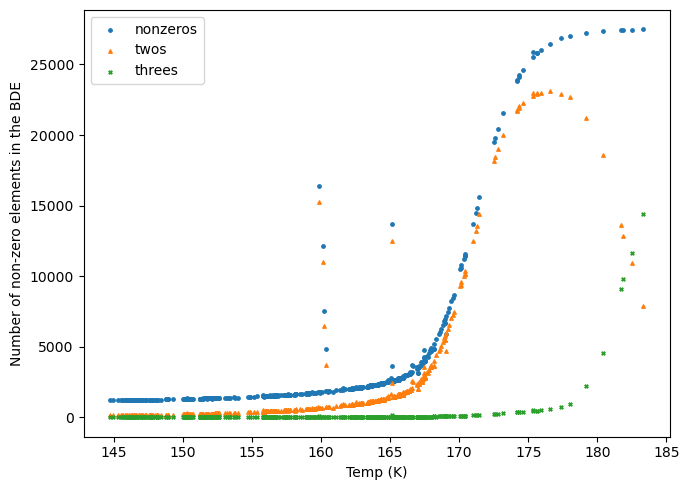

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(m3g['temp'], m3g['nonzeros'], marker='o', s=6, label='nonzeros')
#plt.scatter(m3g['temp'], m3g['ones'], marker='s', s=6, label='ones')
plt.scatter(m3g['temp'], m3g['twos'], marker='^', s=6, label='twos')
plt.scatter(m3g['temp'], m3g['threes'], marker='x', s=6, label='threes')
#plt.scatter(m3g['temp'], m3g['fours'], marker='D', s=6, label='fours')

plt.xlabel("Temp (K)")
plt.ylabel("Number of non-zero elements in the BDE")
plt.legend()
plt.tight_layout()

plt.show()

(array([  6.,   3.,   5.,   5.,   3.,   3.,   5., 212.,  93., 102.]),
 array([283. , 303.7, 324.4, 345.1, 365.8, 386.5, 407.2, 427.9, 448.6,
        469.3, 490. ]),
 <BarContainer object of 10 artists>)

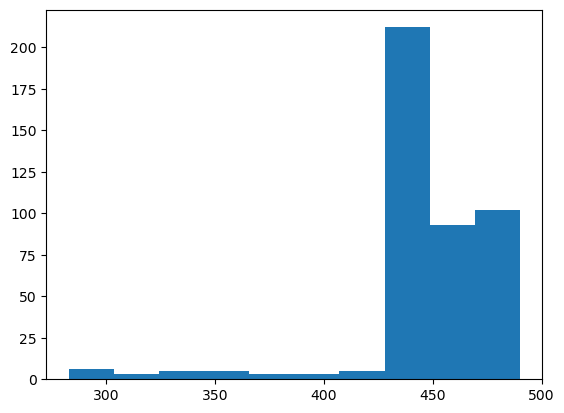

In [27]:
plt.hist(m3g['ones'])

(array([  0.,   0.,   0.,   0.,   0., 437.,   0.,   0.,   0.,   0.]),
 array([639.5, 639.6, 639.7, 639.8, 639.9, 640. , 640.1, 640.2, 640.3,
        640.4, 640.5]),
 <BarContainer object of 10 artists>)

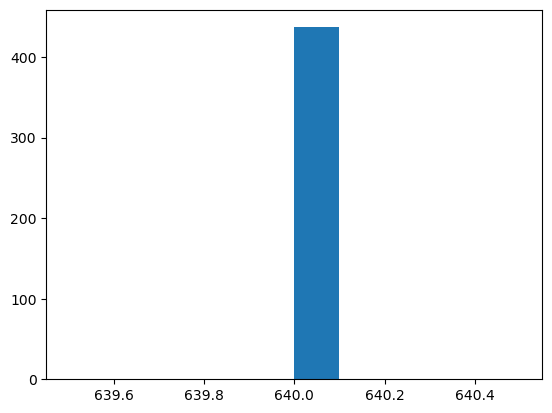

In [29]:
plt.hist(m3g['fours'])